In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [6]:
def _eventISAPhase(session,when='sleep.*#0',n_bins=100,shuffle=0):

    R = fma.regions.regions(session,phases=when,events='InfraSlowRhythm/infraslowaval',load_spikes=False)
    when = R.eventIntervals(when)
    isa = fma.general.intersectIntervals((R.eventIntervals('slownr'),when)) # NO LONGER NECESSARY??
    on = fma.general.intersectIntervals((R.eventIntervals('slowavalnr'),when))
    if on.size == 0:
        return None

    events, is_isa = isru.loadHpcPfcEvents(session,isa=isa)
    events = {e: events[e][is_isa[e]] for e in events} # keep only events in ISA

    # phase of ISA
    isa_phase, on_fraction = isru.ISPhase({0: on[:,0], 2*np.pi: isa[:,1], np.pi: on[:,1]},isa=isa)
    isa_phase_sorted = np.sort(isa_phase[:,1]) # estimation of time occupancy

    # parameters
    bins = np.linspace(0,2*np.pi,n_bins+1)
    bin_width = 2*np.pi / n_bins
    centers = (bins[1:] + bins[:-1]) / 2
    # distribution of ISA phases for tuning curve
    isa_dist = np.full_like(centers,on_fraction)
    isa_dist[centers >= np.pi] = 1 - on_fraction
    isa_dist /= np.trapezoid(isa_dist,centers)

    def histVectorized(x):
        b, a = x.shape
        bin_idx = (x / bin_width).astype(int)
        bin_idx = np.clip(bin_idx,0,n_bins-1)
        offset = np.arange(a)[None,:] * n_bins
        hist = np.bincount((bin_idx+offset).ravel(), minlength=a*n_bins).reshape(a,n_bins).T
        hist = hist / (b * bin_width) # normalize to pdf
        return hist

    dist = np.full((len(events),n_bins,shuffle+1),np.nan) # (events, phase, shuffle)
    dist_transformed = np.full((len(events),n_bins,shuffle+1),np.nan) # (events, phase, shuffle)
    kuramoto = np.full((len(events),2,shuffle+1),np.nan) # (events, value, shuffle)
    for i, e in enumerate(events):

        event_t = events[e] # (times,)
        n_times = len(event_t) # N
        shuffled = fma.general.shuffleEvents(event_t,n=shuffle,intervals=isa,fast=True)
        event_t_flat = np.concatenate((event_t, shuffled.ravel('F')),axis=0) # first N times are observed, next N from first shuffle, (N * (shuffle+1),)
        phases_flat = np.interp(event_t_flat,isa_phase[:,0],isa_phase[:,1]) # (N * (shuffle+1,)
        phases = phases_flat.reshape((n_times,-1),order='F') # (times, shuffle+1)

        # CDF transform, let F(phi) be the empirical CDF of ISA phase
        u = np.searchsorted(isa_phase_sorted,phases_flat,side='right') / len(isa_phase_sorted) # estimate CDF transform of each event's phase, in [0,1]
        u = (u * 2 * np.pi).reshape((n_times,-1),order='F') # transformed phase, uniform if events are uniform w.r.t. ISA phase, (spike, shuffle+1)
        Z = np.mean(np.exp(1j*u),axis=0) # (shuffle+1,)
        kuramoto[i,0] = np.abs(Z)
        kuramoto[i,1] = np.angle(Z)

        # distributions
        dist[i] = histVectorized(phases)
        dist_transformed[i] = histVectorized(u)

    # make distributions walk the full circle
    centers = np.append(centers,centers[-1]+centers[1]-centers[0])
    tuning_curve = dist / isa_dist[None,:,None]
    dist = np.concatenate((dist,dist[:,0:1]),axis=1)
    tuning_curve = np.concatenate((tuning_curve,tuning_curve[:,0:1]),axis=1)
    dist_transformed = np.concatenate((dist_transformed,dist_transformed[:,0:1]),axis=1)

    dist = xr.DataArray(dist,dims=['ev','phi','shuf'],coords={'ev': list(events.keys()), 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    tuning_curve = xr.DataArray(tuning_curve,dims=['ev','phi','shuf'],coords={'ev': list(events.keys()), 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    dist_transformed = xr.DataArray(dist_transformed,dims=['ev','phi','shuf'],coords={'ev': list(events.keys()), 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)}) # 'p': ('event', p),

    p_val = fma.analysis.MCpValue(kuramoto[:,0,1:].T,kuramoto[:,0,0]) # Monte Carlo p-value
    kuramoto[:,1] = np.mod(kuramoto[:,1],2*np.pi) # remap psi in [0, 2pi]
    kuramoto = xr.DataArray(kuramoto,dims=['ev','val','shuf'],coords={'ev': list(events.keys()), 'MC': ('ev', p_val), 'val': ['R','psi'], 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})

    return kuramoto, dist, tuning_curve, dist_transformed, isa_phase

In [9]:
session = fma.data.readBatchFile(batch_file)[0][15]
print(session)
kuramoto, dist, tuning_curve, dist_transformed, isa_phase = _eventISAPhase(session,n_bins=60,shuffle=15)

/mnt/hubel-data-139/karadoc/Rat004_20240227/Rat004_20240227.xml


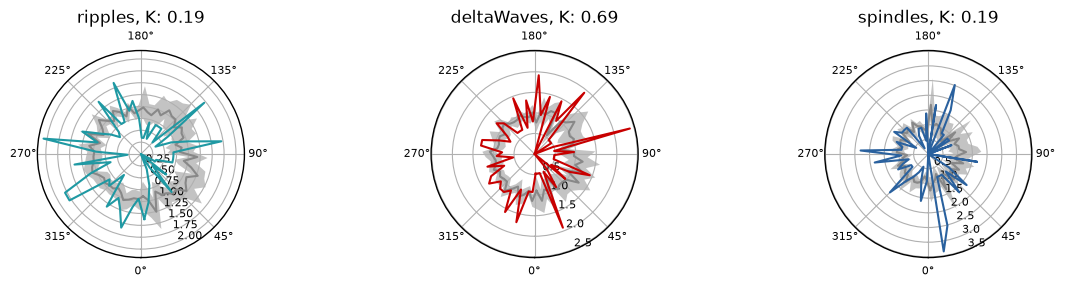

In [10]:
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(30,7),projection='polar')
for i, e in enumerate(tuning_curve.ev.values):
    tc = tuning_curve.sel(ev=e)
    tk = kuramoto.sel(ev=e)
    ax[i].set_theta_zero_location('S')
    ax[i].set_title(f'{e}, K: {tk.MC.values:.2f}')
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=True).T,color=isru.paperColors('shuffle'),ax=ax[i])
    ax[i].plot(tuning_curve.phi,tc.sel(shuf=False),color=isru.paperColors(e))

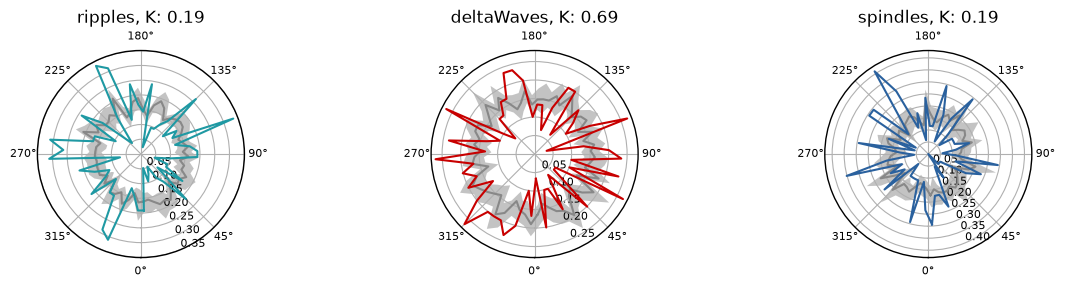

In [11]:
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(30,7),projection='polar')
for i, e in enumerate(dist_transformed.ev.values):
    tc = dist_transformed.sel(ev=e)
    tk = kuramoto.sel(ev=e)
    ax[i].set_theta_zero_location('S')
    ax[i].set_title(f'{e}, K: {tk.MC.values:.2f}')
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=True).T,color=isru.paperColors('shuffle'),ax=ax[i])
    ax[i].plot(tuning_curve.phi,tc.sel(shuf=False),color=isru.paperColors(e))

Run batch

In [17]:
kuramoto, dist, tuning_curve, dist_transformed, isa_phase  = fma.data.runBatch(batch_file,_eventISAPhase,kwargs={'n_bins': 50, 'shuffle': 1000},parallel=True)
dist_transformed_cat = xr.concat([d for d in dist_transformed if d is not None],dim='rat',join='outer')
dist_transformed_avg = dist_transformed_cat.groupby('rat').mean(dim='rat',skipna=True)
tuning_curve_cat = xr.concat([d for d in tuning_curve if d is not None],dim='rat',join='outer')
tuning_curve_avg = tuning_curve_cat.groupby('rat').mean(dim='rat',skipna=True)
kuramoto_cat = xr.concat([d for d in kuramoto if d is not None],dim='rat',coords='different',join='outer')


Starting Batch, 2026-07-24 12:37:16.467197 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml (35)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230817/Rat002_20230817.xml (36)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230818/Rat002_20230818.xml (37)
only integer scalar array

/tmp/ipykernel_3038749/4257808973.py:6: FutureWarning: In a future version of xarray the default value for compat will change from compat='equals' to compat='override'. This change will result in the following ValueError: Cannot specify both coords='different' and compat='override'. The recommendation is to set compat explicitly for this case.
  kuramoto_cat = xr.concat([d for d in kuramoto if d is not None],dim='rat',coords='different',join='outer')


In [25]:
# test
p_val = {e: fma.analysis.maxStatisticTest(kuramoto_cat.sel(ev=e,val='R',shuf=False).values[:,None],
                                          kuramoto_cat.sel(ev=e,val='R',shuf=True).values[:,None], group=kuramoto_cat.rat)
         for e in kuramoto_cat.ev.values}

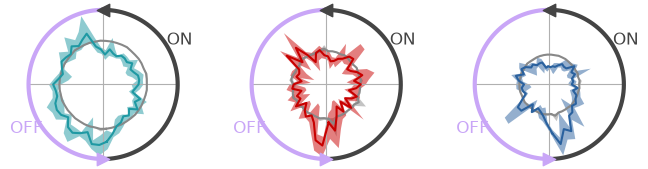

In [35]:
# CHANGE PADDING HERE ALSO
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(17,4),projection='polar')
for i, e in enumerate(tuning_curve_avg.ev.values):
    tc = tuning_curve_avg.sel(ev=e)
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=True).mean(dim='shuf'),color=isru.paperColors('shuffle'),ax=ax[i])
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=False),color=isru.paperColors(e),ax=ax[i],smooth=1)
isru.ISAxes(ax)

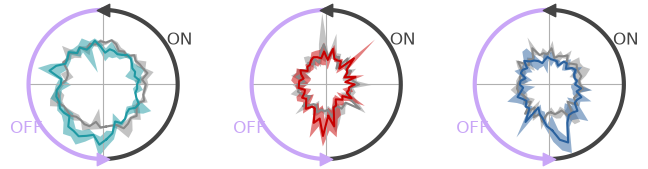

In [34]:
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(17,4),projection='polar')
for i, e in enumerate(dist_transformed_avg.ev.values):
    tc = dist_transformed_avg.sel(ev=e)
    fma.plotting.semPlot(tc.phi,tc.isel(shuf=5),color=isru.paperColors('shuffle'),ax=ax[i])
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=False),color=isru.paperColors(e),ax=ax[i])
isru.ISAxes(ax)

Test ISPhase

In [8]:
def _ISAPhase(session):

    R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval',load_spikes=False)
    isa = R.eventIntervals('slownr')
    on = R.eventIntervals('slowavalnr')
    isa_phase = isru.ISPhase({0: on[:,0], 2*np.pi: isa[:,1], np.pi: on[:,1]},isa=isa)

    return isa, on, isa_phase

In [9]:
session = fma.data.readBatchFile(batch_file)[0][30]
print(session)
isa, on, isa_phase = _ISAPhase(session)

/mnt/hubel-data-140/karadoc/Rat004_20240319/Rat004_20240319.xml


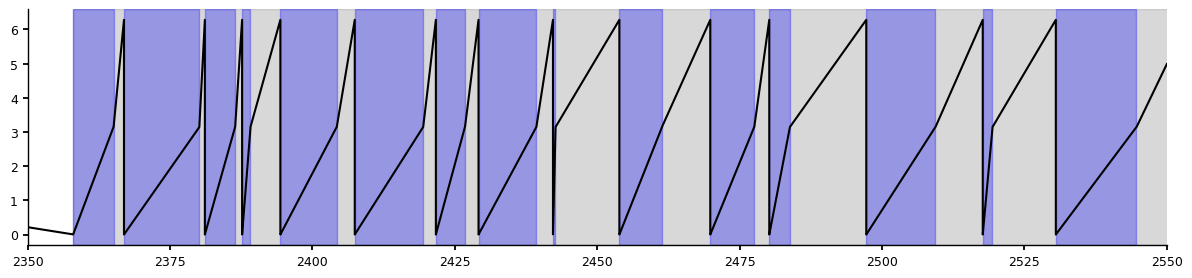

In [10]:
fig, ax = fma.plotting.makeFigure(size=(30,7))
fma.plotting.plotXY(isa_phase,ax=ax[0],color='k')
fma.plotting.plotIntervals(isa,ax=ax[0])
fma.plotting.plotIntervals(on,color='b',ax=ax[0])
ax[0].set(xlim=[2350,2550]);

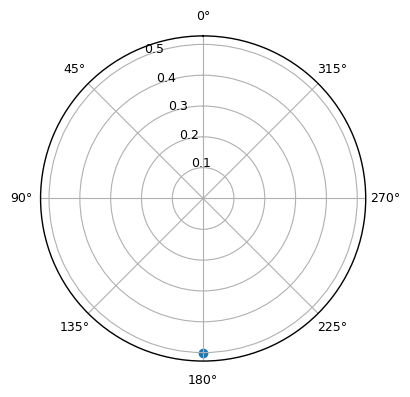

In [27]:
fig, ax = fma.plotting.makeFigure(projection='polar')
ax[0].set_theta_zero_location('N')
ax[0].scatter(np.pi,0.5)